# 04 — Scoring & Visualization

Score all nodes using the trained WGAN-GP anomaly detector, set a threshold,
evaluate detection performance, and visualize results.

In [26]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix,
)

from gan_anomaly import (
    Discriminator, Generator, Encoder, anomaly_score,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("results", exist_ok=True)

## 1. Load Models, Embeddings & Metadata

In [27]:
# Load hyperparams
with open("models/training_meta.json") as f:
    meta = json.load(f)

INPUT_DIM = meta["input_dim"]
LATENT_DIM = meta["latent_dim"]

# Reconstruct and load models
G = Generator(LATENT_DIM, INPUT_DIM, meta["g_hidden"], meta["n_layers"], meta["activation"]).to(device)
E = Encoder(INPUT_DIM, LATENT_DIM, meta["e_hidden"], meta["n_layers"], meta["activation"]).to(device)

G.load_state_dict(torch.load("models/generator.pt", map_location=device, weights_only=True))
E.load_state_dict(torch.load("models/encoder.pt", map_location=device, weights_only=True))
G.eval(); E.eval()

# Load data
embeddings = np.load("embeddings/node_embeddings.npy")
node_ids = np.load("embeddings/node_ids.npy", allow_pickle=True)
node_features = pd.read_parquet("data/node_features.parquet")
X_train = np.load("models/X_train.npy")
X_eval = np.load("models/X_eval.npy")
y_eval = np.load("models/y_eval.npy")

print(f"Loaded models (input_dim={INPUT_DIM}, latent_dim={LATENT_DIM})")
print(f"All nodes: {len(embeddings):,}")

Loaded models (input_dim=64, latent_dim=16)
All nodes: 7,500


## 2. Score All Nodes

In [28]:
all_tensor = torch.tensor(embeddings, dtype=torch.float32).to(device)
all_scores = anomaly_score(all_tensor, E, G).cpu().numpy()

print(f"Score range: [{all_scores.min():.4f}, {all_scores.max():.4f}]")
print(f"Score mean:  {all_scores.mean():.4f}")
print(f"Score std:   {all_scores.std():.4f}")

Score range: [0.0701, 302.1164]
Score mean:  0.8863
Score std:   4.3986


## 3. Set Threshold (99th Percentile of Training Scores)

In [29]:
train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
train_scores = anomaly_score(train_tensor, E, G).cpu().numpy()

THRESHOLD_PERCENTILE = 99
threshold = np.percentile(train_scores, THRESHOLD_PERCENTILE)

print(f"Threshold ({THRESHOLD_PERCENTILE}th percentile of training scores): {threshold:.4f}")

Threshold (99th percentile of training scores): 6.0661


## 4. Build Results Table

In [30]:
# Get SAR labels for all nodes
is_sar_all = node_features.set_index("id")["is_sar"].reindex(node_ids).fillna(0).astype(int).values

# Normalize scores to 0-100 risk scale
score_min, score_max = all_scores.min(), all_scores.max()
risk_score = (all_scores - score_min) / (score_max - score_min) * 100

results = pd.DataFrame({
    "id": node_ids,
    "anomaly_score": all_scores,
    "risk_score": risk_score,
    "is_anomaly": all_scores > threshold,
    "is_sar": is_sar_all,
})

# Merge with node features for context
results = results.merge(node_features.drop(columns=["is_sar"]), on="id", how="left")

print(f"Flagged as anomaly: {results['is_anomaly'].sum():,} / {len(results):,}")
print(f"True SAR nodes:     {results['is_sar'].sum():,}")
results.sort_values("anomaly_score", ascending=False).head(20)

Flagged as anomaly: 87 / 7,500
True SAR nodes:     644


,id,anomaly_score,risk_score,is_anomaly,is_sar,type,out_degree,total_amount_sent,avg_amount_sent,unique_counterparties_sent,in_degree,total_amount_received,avg_amount_received,unique_counterparties_received
1,c5dccde2,302.116394,100.000000,True,0,1,164241.0,87578767.05,533.233279,6742.0,67431.0,36058101.35,534.740718,2884.0
4960,0ed1750d,115.421951,38.190113,True,1,0,1.0,463.61,463.610000,1.0,18.0,125017.46,6945.414444,4.0
2,34cdefef,75.650391,25.022741,True,0,0,58454.0,31185531.35,533.505515,4601.0,79715.0,42534054.01,533.576542,1644.0
4114,ab35a7fd,64.877731,21.456182,True,1,0,0.0,0.00,0.000000,0.0,8.0,59297.69,7412.211250,2.0
4,c613c146,55.124039,18.226978,True,0,1,20514.0,10993727.32,535.913392,2544.0,19114.0,10223886.30,534.889939,934.0
5,7b808486,49.428200,16.341227,True,0,1,14997.0,8014586.82,534.412671,2034.0,13772.0,7340243.33,532.983106,765.0
6,308e3438,48.376961,15.993188,True,0,1,11094.0,5902121.83,532.010261,1681.0,10945.0,5870136.61,536.330435,696.0
3,c1bfb464,45.820923,15.146949,True,1,0,31934.0,17051866.28,533.972139,3262.0,30611.0,16325916.80,533.334971,1174.0
5132,e6ccbd74,45.616081,15.079130,True,1,0,2.0,1075.72,537.860000,2.0,17.0,121367.74,7139.278824,3.0
3239,3499edce,42.581978,14.074614,True,1,1,3.0,1309.11,436.370000,2.0,20.0,129565.11,6478.255500,3.0


## 5. Evaluation Metrics (on Eval Set)

In [31]:
eval_tensor = torch.tensor(X_eval, dtype=torch.float32).to(device)
eval_scores = anomaly_score(eval_tensor, E, G).cpu().numpy()

auc = roc_auc_score(y_eval, eval_scores)
ap = average_precision_score(y_eval, eval_scores)

# Classification at threshold
y_pred = (eval_scores > threshold).astype(int)

print(f"ROC AUC:            {auc:.4f}")
print(f"Average Precision:  {ap:.4f}")
print(f"\nClassification Report (threshold={threshold:.4f}):")
print(classification_report(y_eval, y_pred, target_names=["Non-SAR", "SAR"]))
print("Confusion Matrix:")
print(confusion_matrix(y_eval, y_pred))

ROC AUC:            0.6528
Average Precision:  0.4348

Classification Report (threshold=6.0661):
              precision    recall  f1-score   support

     Non-SAR       0.68      0.99      0.81      1372
         SAR       0.50      0.02      0.05       644

    accuracy                           0.68      2016
   macro avg       0.59      0.51      0.43      2016
weighted avg       0.62      0.68      0.57      2016

Confusion Matrix:
[[1356   16]
 [ 628   16]]


## 6. ROC Curve

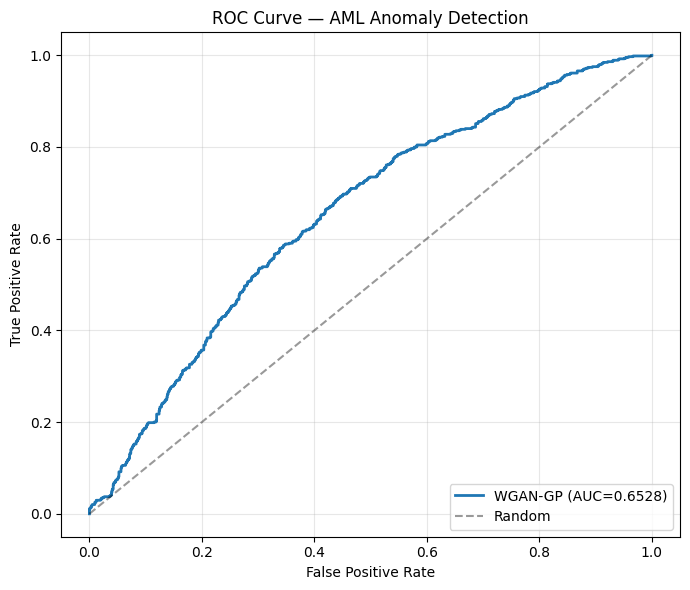

In [32]:
fpr, tpr, _ = roc_curve(y_eval, eval_scores)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"WGAN-GP (AUC={auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — AML Anomaly Detection")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/roc_curve.png", dpi=150)
plt.show()

## 7. Precision-Recall Curve

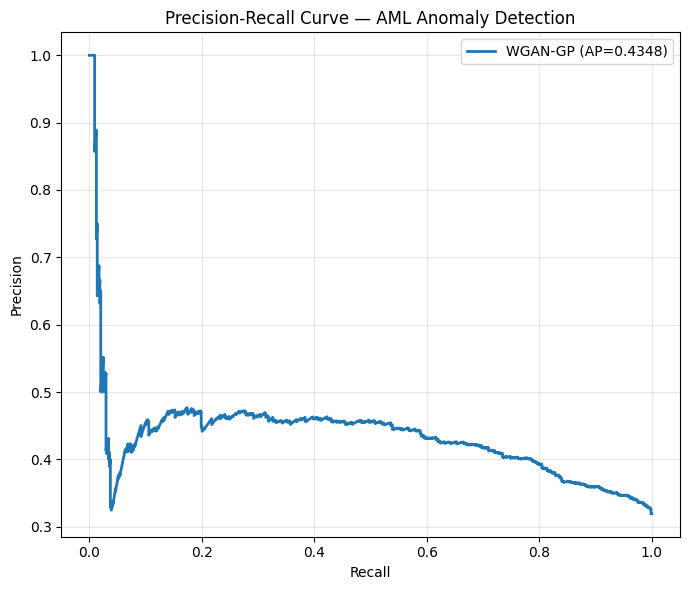

In [33]:
precision, recall, _ = precision_recall_curve(y_eval, eval_scores)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, linewidth=2, label=f"WGAN-GP (AP={ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — AML Anomaly Detection")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/pr_curve.png", dpi=150)
plt.show()

## 8. Anomaly Score Distribution

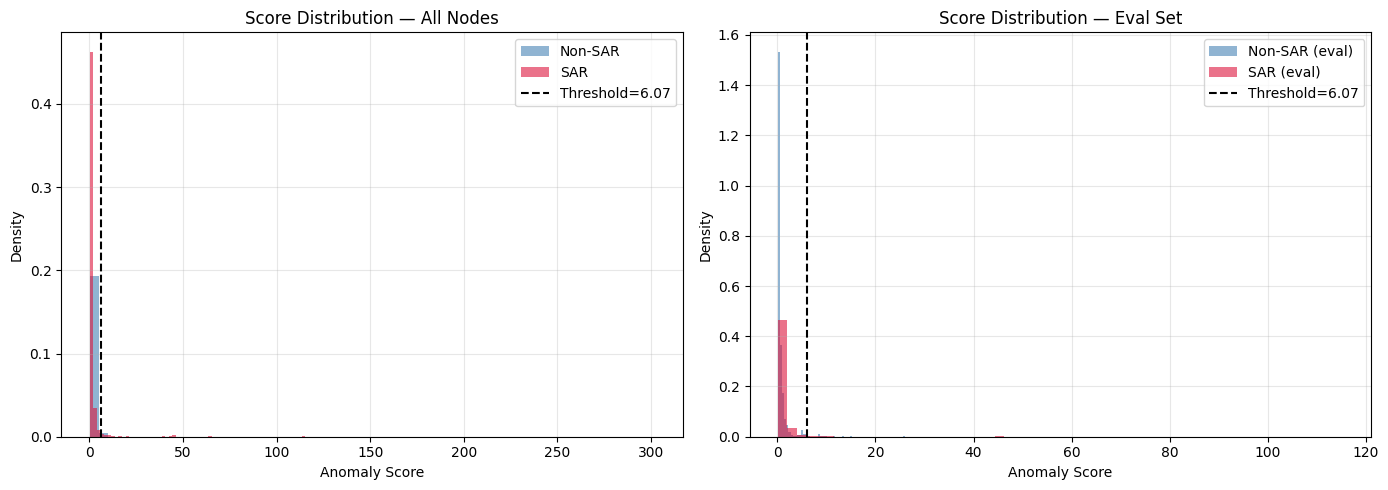

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All nodes
ax = axes[0]
sar_scores = all_scores[is_sar_all == 1]
nonsar_scores = all_scores[is_sar_all == 0]
ax.hist(nonsar_scores, bins=60, alpha=0.6, label="Non-SAR", density=True, color="steelblue")
ax.hist(sar_scores, bins=60, alpha=0.6, label="SAR", density=True, color="crimson")
ax.axvline(threshold, color="black", linestyle="--", label=f"Threshold={threshold:.2f}")
ax.set_xlabel("Anomaly Score")
ax.set_ylabel("Density")
ax.set_title("Score Distribution — All Nodes")
ax.legend()
ax.grid(True, alpha=0.3)

# Eval set
ax = axes[1]
ax.hist(eval_scores[y_eval == 0], bins=60, alpha=0.6, label="Non-SAR (eval)", density=True, color="steelblue")
ax.hist(eval_scores[y_eval == 1], bins=60, alpha=0.6, label="SAR (eval)", density=True, color="crimson")
ax.axvline(threshold, color="black", linestyle="--", label=f"Threshold={threshold:.2f}")
ax.set_xlabel("Anomaly Score")
ax.set_ylabel("Density")
ax.set_title("Score Distribution — Eval Set")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/score_distributions.png", dpi=150)
plt.show()

## 9. Top Anomalous Nodes

In [35]:
top_n = 30
top_anomalies = results.nlargest(top_n, "anomaly_score")

display_cols = [
    "id", "risk_score", "is_sar", "type",
    "in_degree", "out_degree",
    "total_amount_sent", "total_amount_received",
    "unique_counterparties_sent", "unique_counterparties_received",
]
print(f"\nTop {top_n} Most Suspicious Accounts:")
top_anomalies[display_cols]


Top 30 Most Suspicious Accounts:


,id,risk_score,is_sar,type,in_degree,out_degree,total_amount_sent,total_amount_received,unique_counterparties_sent,unique_counterparties_received
1,c5dccde2,100.000000,0,1,67431.0,164241.0,87578767.05,36058101.35,6742.0,2884.0
4960,0ed1750d,38.190113,1,0,18.0,1.0,463.61,125017.46,1.0,4.0
2,34cdefef,25.022741,0,0,79715.0,58454.0,31185531.35,42534054.01,4601.0,1644.0
4114,ab35a7fd,21.456182,1,0,8.0,0.0,0.00,59297.69,0.0,2.0
4,c613c146,18.226978,0,1,19114.0,20514.0,10993727.32,10223886.30,2544.0,934.0
5,7b808486,16.341227,0,1,13772.0,14997.0,8014586.82,7340243.33,2034.0,765.0
6,308e3438,15.993188,0,1,10945.0,11094.0,5902121.83,5870136.61,1681.0,696.0
3,c1bfb464,15.146949,1,0,30611.0,31934.0,17051866.28,16325916.80,3262.0,1174.0
5132,e6ccbd74,15.079130,1,0,17.0,2.0,1075.72,121367.74,2.0,3.0
3239,3499edce,14.074614,1,1,20.0,3.0,1309.11,129565.11,2.0,3.0


## 10. Detection Rate by Risk Band

In [36]:
results["risk_band"] = pd.cut(
    results["risk_score"],
    bins=[0, 30, 60, 80, 100],
    labels=["Low (0-30)", "Medium (30-60)", "High (60-80)", "Critical (80-100)"],
)

band_summary = results.groupby("risk_band", observed=True).agg(
    total_nodes=("id", "count"),
    sar_nodes=("is_sar", "sum"),
).assign(
    sar_rate=lambda x: (x["sar_nodes"] / x["total_nodes"] * 100).round(1)
)

print("Risk Band Summary:")
band_summary

Risk Band Summary:


,total_nodes,sar_nodes,sar_rate
risk_band,,,
Low (0-30),7497,643,8.6
Medium (30-60),1,1,100.0
Critical (80-100),1,0,0.0


## 11. Save Results

In [37]:
results.to_parquet("results/anomaly_scores.parquet", index=False)

eval_metrics = {
    "roc_auc": float(auc),
    "average_precision": float(ap),
    "threshold": float(threshold),
    "threshold_percentile": THRESHOLD_PERCENTILE,
    "total_nodes": int(len(results)),
    "flagged_anomalies": int(results["is_anomaly"].sum()),
    "true_sar_nodes": int(results["is_sar"].sum()),
}
with open("results/evaluation_metrics.json", "w") as f:
    json.dump(eval_metrics, f, indent=2)

print("Saved:")
print("  results/anomaly_scores.parquet")
print("  results/evaluation_metrics.json")
print("  results/roc_curve.png")
print("  results/pr_curve.png")
print("  results/score_distributions.png")
print(f"\nFinal ROC AUC: {auc:.4f}")

Saved:
  results/anomaly_scores.parquet
  results/evaluation_metrics.json
  results/roc_curve.png
  results/pr_curve.png
  results/score_distributions.png

Final ROC AUC: 0.6528


In [38]:
# ── GPU Cleanup — free VRAM for next notebook ──
import gc
for v in ["G", "E", "all_tensor", "train_tensor", "eval_tensor"]:
    if v in dir():
        exec(f"del {v}")
torch.cuda.empty_cache(); gc.collect()
print(f"GPU freed: {torch.cuda.memory_allocated()/1e6:.1f} MB allocated")

GPU freed: 8.5 MB allocated
